# MA-XRF refactored 

*Rethinking our dashboard code we need to be able to explore and annotate the hotmax spectra for regions of interest.*

First run **Functions** code cells below. 

In [2]:
print(f'falnama: {fn.__version__}\nmaxrf4u: {mx.__version__}') 

falnama: 0.0.1
maxrf4u: 0.1.42


## Overview of all datastacks

In [4]:
data = fn.Falnama_maxrf_data()

data.get_base_path()

datastack_files = data.get_datastack_files()
datastack_files

['/home/frank/.cache/falnama/WM-71803-01_400_600_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-03_250_300_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-08_250_300_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-10_250_300_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-12_250_300_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-13_400_600_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-17_400_600_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-18_400_300_50_det.datastack',
 '/home/frank/.cache/falnama/WM-71803-18_400_500_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-19_400_600_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-23_400_600_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-24_400_600_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-29_400_500_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-30_250_300_50.datastack',
 '/home/frank/.cache/falnama/WM-71803-31_400_600_50.datastack',
 '/home/frank/.cache/falnama/WM-7180

In [5]:
%matplotlib widget

In [6]:
imvis_list = []
extent_list = []
for datastack_file in datastack_files: 
    ds = mx.DataStack(datastack_file)
    im = ds.read('imvis_reg')
    extent = ds.read('imvis_extent')
    imvis_list.append(im)
    extent_list.append(extent) 

object_nums = [re.sub(r'.*(WM-71803-\d\d).*', r'\1', dsf) for dsf in datastack_files]

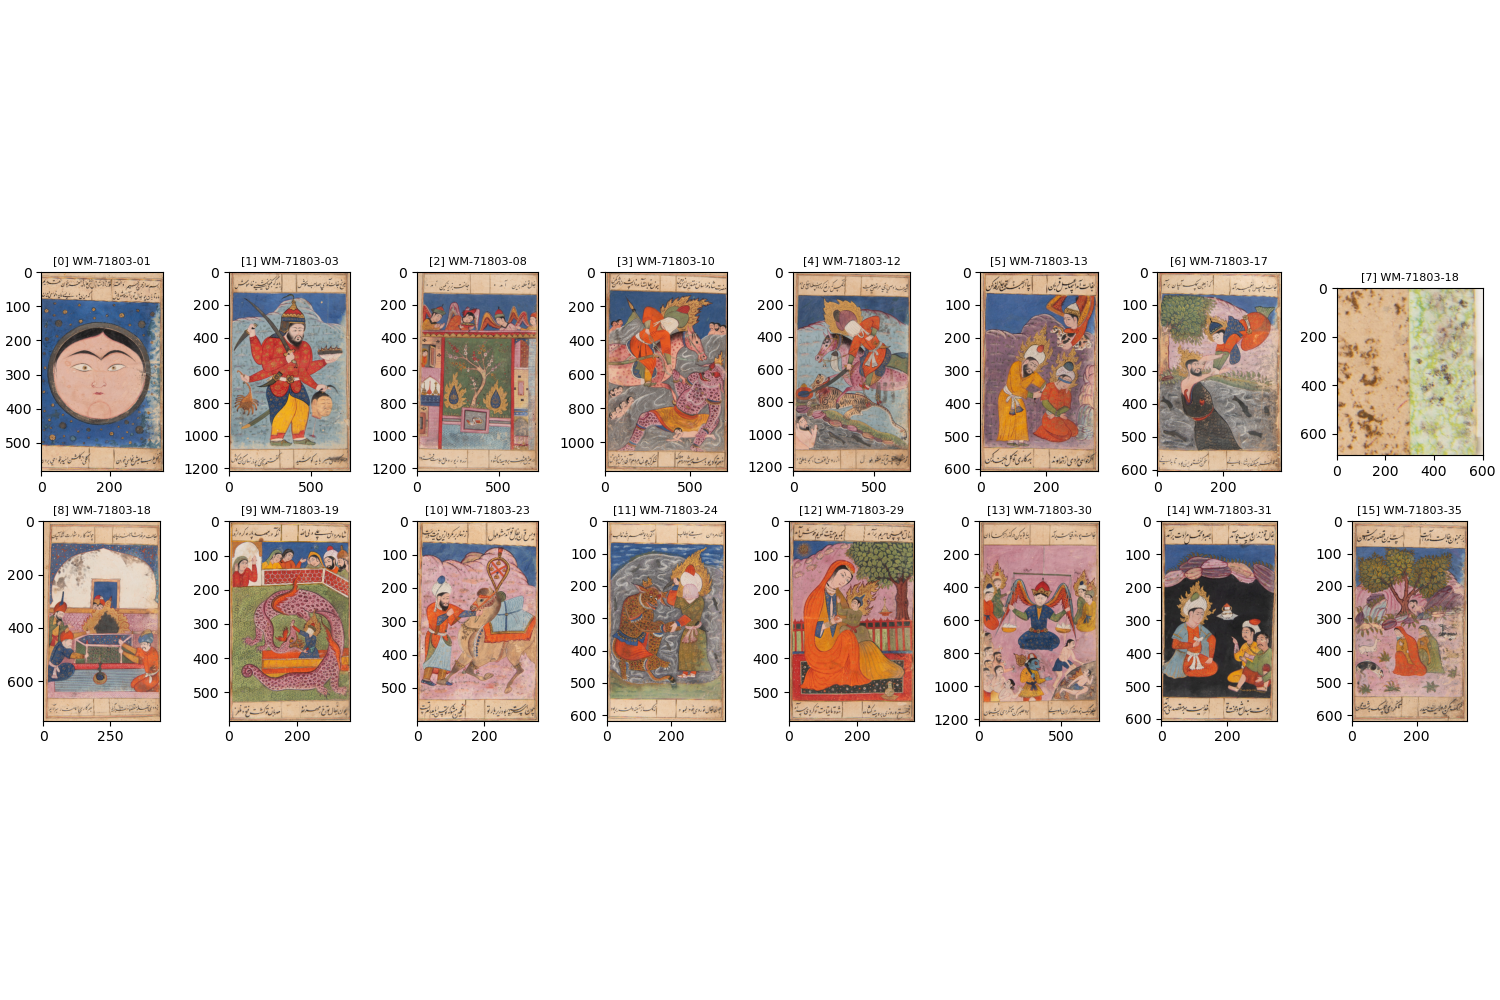

In [7]:
fig, axs = plt.subplots(ncols=8, nrows=2, figsize=[15, 10], layout='compressed')
axs = axs.flatten()
for i, [im, ax, extent] in enumerate(zip(imvis_list, axs, extent_list)): 
    ax.imshow(im, extent=extent)
    ax.set_title(f'[{i}] {object_nums[i]}', fontsize=8)

# Regions of interest for page 35 (index 15)

In [8]:
n = 15
datastack_file = datastack_files[n]
ds = mx.DataStack(datastack_file)

object_num = object_nums[n]

cube = ds.read('maxrf_cube', compute=False)
imvis_highres = ds.read('imvis_reg_highres')
imvis = ds.read('imvis_reg')
extent = ds.read('imvis_extent')
x_keVs = ds.read('maxrf_energies')
y_maxspectrum = ds.read('maxrf_maxspectrum')

nmf_elementmaps = ds.read('nmf_elementmaps') 

ppa = mx.Peak_Pattern_Atlas(datastack_file=datastack_file, tube_keV=23)

ds.tree()

Please wait while initializing peak pattern atlas...


/
├── compton_peak_energy (1,) float64
├── hotmax_baselines (31, 4096) float64
├── hotmax_noiselines (31, 4096) float64
├── hotmax_peak_idxs_flat (34,) int64
├── hotmax_peak_idxs_list (31, 2) int64
├── hotmax_spectra (31, 4096) float32
├── hotmax_spots (31, 2) int64
├── hotmax_subpeak_idxs_list (31, 18) int64
├── imvis_extent (4,) int64
├── imvis_reg (617, 357, 3) uint8
├── imvis_reg_highres (8256, 4777, 3) uint8
├── maxrf_cube (617, 357, 4096) float32
├── maxrf_energies (4096,) float64
├── maxrf_maxspectrum (4096,) float32
├── maxrf_sumspectrum (4096,) float64
├── nmf_atomnums (18,) int64
├── nmf_elementmaps (18, 617, 357) float32
├── nmf_gausscomponents (35, 4096) float32
├── nmf_peakmaps (35, 617, 357) float32
└── nmf_peaks2elements_matrix (18, 34) float32

/home/frank/.cache/falnama/WM-71803-35_400_500_50.datastack:




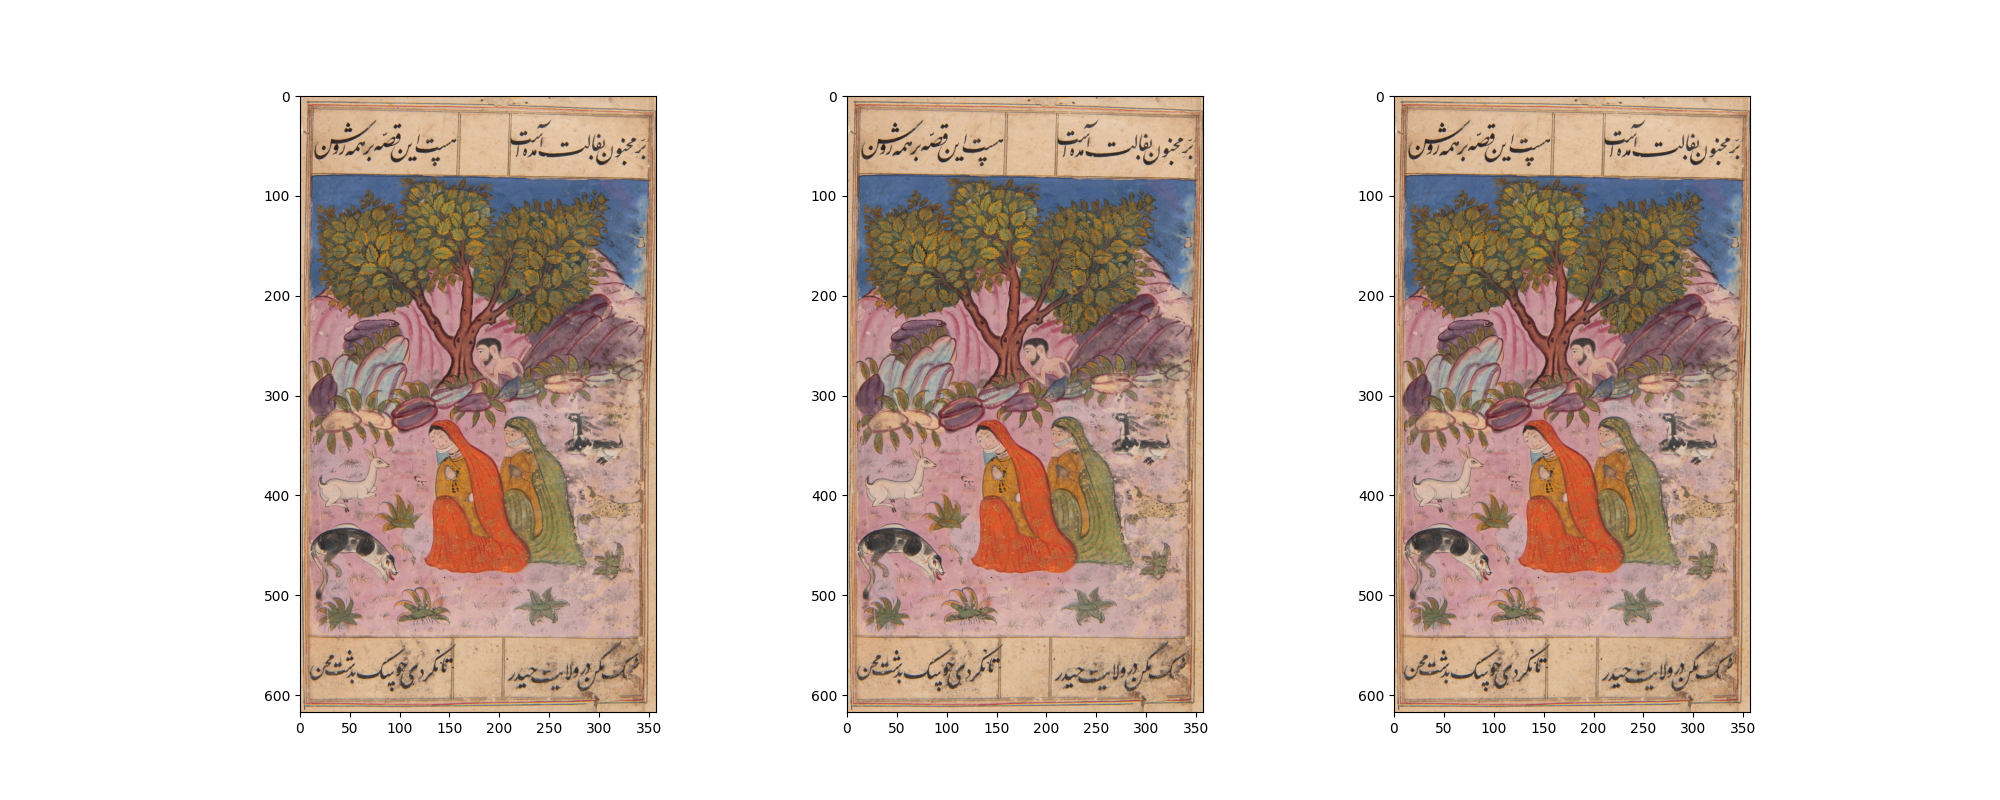

In [27]:
# uncomment and run this cell to create regions of interest
fig, axs = plt.subplots(ncols=3, figsize=[20, 8], squeeze=True)
for ax in axs: 
    ax.imshow(imvis_highres, extent=extent)



In [28]:
extra_xylims_list = [[int(ax.get_xlim()[0]), int(ax.get_xlim()[1]), int(ax.get_ylim()[0]), int(ax.get_ylim()[1])] for ax in axs]
extra_xylims_list

[[152, 189, 239, 213], [51, 98, 179, 141], [163, 186, 587, 559]]

In [9]:
xylims_list = [[140, 162, 464, 435], [137, 151, 398, 385], [250, 268, 461, 436], [93, 127, 458, 435], [60, 86, 292, 268], [33, 58, 101, 83], [152, 189, 239, 213], [51, 98, 179, 141]]
len(xylims_list)

8

In [10]:
roi_cubes = [cube[l:k, i:j].compute() for i, j, k, l in xylims_list]
roi_ims = get_roi_ims(datastack_file, xylims_list)

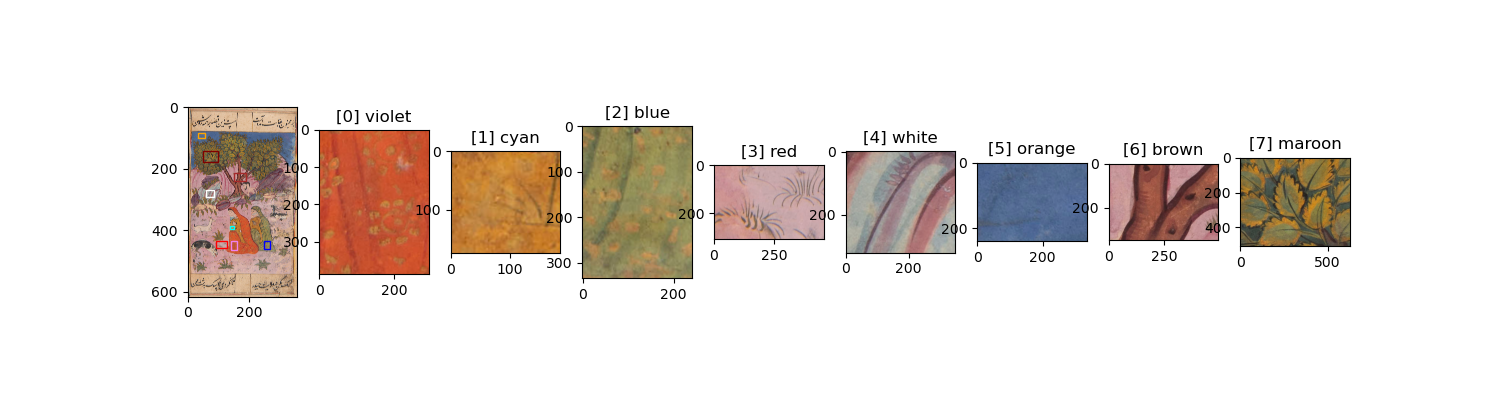

In [11]:
fig, axs = plt.subplots(ncols=len(roi_ims)+1, figsize=[15, 4], squeeze=True)

edgecolors = ['violet', 'cyan', 'blue', 'red', 'white', 'orange', 'brown', 'maroon']

axs[0].imshow(imvis_highres, extent=extent)

for i, xylims in enumerate(xylims_list):
    x0, x1, y0, y1 = xylims
    axs[0].add_patch(Rectangle([x0, y1], x1 -x0, y0 - y1, linewidth=1, edgecolor=edgecolors[i], facecolor='none'))

for i, [ax, im] in enumerate(zip(axs[1:], roi_ims)): 
    
    ax.imshow(im)
    #imvis_highres[l:k,i:j]
    #ax.set_xlim(xylims_list[i][0:2])
    #ax.set_ylim(xylims_list[i][2:4])
    ax.set_title(f'[{i}] {edgecolors[i]}')
    

And here are the hotmax spectra for all regions of interest.

In [39]:
plt.close('all')

In [130]:
roi_elements_list = [['Au', 'Pb'], ['Au', 'As', 'Fe', 'Ca'], ['As', 'Au', 'Fe', 'Ca'], ['Pb', 'Fe'], ['Pb', 'Fe'], ['Ca', 'K', 'Pb', 'Fe'], ['Fe', 'Hg', 'Pb'], ['As', 'Pb', 'Fe', 'Ca']]

In [131]:
plot_roi_dashboard(roi_cubes[0:2], roi_ims[0:2], roi_elements_list[0:2], nmf_elementmaps) 

On my laptop rendering of the 8 roi tab figures requires 1:08 minutes. Perhaps we could improve this following the ipympl instructions: https://matplotlib.org/ipympl/examples/full-example.html#update-image-data-in-a-performant-manner, but let's stick with the current multi figure plotting strategy for now to minimize 

In [58]:
def plot_roi_dashboard(roi_cubes, roi_ims, roi_elements_list, nmf_elementmaps): 
    '''Create tabbed plot for roi spectra. '''
    
    # initialize tabs 
    sub_tab=[widgets.Output() for i in range(len(roi_cubes))]
    tab = widgets.Tab(sub_tab)
    for roi_n in range(len(roi_cubes)):
        tab.set_title(roi_n, f'ROI [{roi_n}]')
        print(f'Rendering dashboard tab for ROI {roi_n}/{len(roi_cubes) -1}...', end='\r') 
    
        with sub_tab[roi_n]: 
       
            # roi cube (core) maxspectrum 
            hotmax_idxs, spectra = get_hotmax_spectra(roi_cubes[roi_n])
            roi_cube = roi_cubes[roi_n]
            roi_h, roi_w, roi_d = roi_cube.shape
            roi_flat = roi_cube.reshape([-1, roi_d])
            roi_maxspectrum = roi_flat.max(axis=0) # actually this is the roi core max spectrum  

            roi_elements = roi_elements_list[roi_n]
            
            # create sub figures and their axes 
            fig = plt.figure(layout='constrained', figsize=(15, 7))
            subfigs = fig.subfigures(ncols=2, wspace=0.07, width_ratios=[2, 1], squeeze=True) #

            # left top and bottom figures
            leftfigs = subfigs[0].subfigures(nrows=2, wspace=0.07, height_ratios=[1, 2]) 
            topleft_axs = leftfigs[0].subplots(ncols=len(roi_elements) + 1, squeeze=True) # ncols actually depends on number of elements 
            botleft_axs = leftfigs[1].subplots(ncols=len(roi_elements) + 1, squeeze=True, sharex=True, sharey=True) # same  

            # create spectral axes for right figure,
            axs_right = subfigs[1].subplots(nrows=2, squeeze=True, sharex=True) 
            
            # PLOTS 
            
            # plot roi RGB image in top left figure  
            topleft_axs[0].imshow(roi_ims[roi_n], extent=[0, roi_w, roi_h, 0]) 
            topleft_axs[0].set_title(f'ROI [{roi_n}]')
            
            topleft_axs[0].add_patch(Rectangle([0, 0], roi_w, roi_h, linewidth=5, edgecolor=edgecolors[roi_n], facecolor='none'))
 
            yi, xi = hotmax_idxs[:, 0:2].T
            topleft_axs[0].scatter(xi, yi, color='w', marker='+') 

            # plot roi element maps in top left figure  
            alpha_idxs, roi_maps = get_roi_maps(roi_cube, roi_elements, x_keVs, exc_keV=23)
            
            for ax, im, element in zip(topleft_axs[1:], roi_maps, roi_elements): 
                ax.imshow(im, vmin=0)
                ax.set_title(f'{element} (slice)')
                      
            
            # plot overview RGB image in bottom left figure  
            botleft_axs[0].imshow(imvis_highres, extent=extent)
            botleft_axs[0].set_title(object_num)
            for i, xylims in enumerate(xylims_list):
                x0, x1, y0, y1 = xylims
                botleft_axs[0].add_patch(Rectangle([x0, y1], x1 -x0, y0 - y1, linewidth=1, edgecolor=edgecolors[i], facecolor='none'))
                botleft_axs[0].annotate(f'ROI {i}', xy=[x0, y1], xytext=[0,5], textcoords='offset points', color='w', fontsize=8)

            # plot full NMF element maps in bottom left figure 
            for ax, element in zip(botleft_axs[1:], roi_elements): 
                nmf_map = pick_nmf_elementmap(datastack_file, nmf_elementmaps, element) # global!!
                
                ax.imshow(nmf_map, vmin=0)
                ax.set_title(f'{element} (NMF)')
                for i, xylims in enumerate(xylims_list):
                    x0, x1, y0, y1 = xylims
                    ax.add_patch(Rectangle([x0, y1], x1 -x0, y0 - y1, linewidth=1, edgecolor=edgecolors[i], facecolor='none'))
                    ax.annotate(f'ROI {i}', xy=[x0, y1], xytext=[0,5], textcoords='offset points', color='w', fontsize=8)
            
            # plot roi patterns (for now let's not plot this)
            #peak_idxs_list = plot_roi_peak_patterns(roi_cubes[roi_n], ax=axs_right[0])
            
            # plot max spectrum and element lines 
            axs_right[0].plot(x_keVs, roi_maxspectrum)
            axs_right[0].plot(x_keVs, y_maxspectrum, color='r', alpha=0.1)
            for element in roi_elements_list[roi_n]:
                plot_element_lines(element, x_keVs, ax=axs_right[0], color=mx.colorize(element), y=roi_maxspectrum)

            axs_right[0].set_xlim([-1, 25])
            axs_right[0].set_xlabel('energy [keV]')

            # plot peak pattern atlas 
            ppa.plot_patterns(ax=axs_right[1], select_elems=roi_elements_list[roi_n])

            plt.suptitle(object_num)
            
            plt.show(fig)

    print(' '*50) # clear message line 
    display(tab)

# Functions 

In [60]:
import falnama as fn
import matplotlib.pyplot as plt
import maxrf4u as mx  
import moseley as mos
import numpy as np
import scipy.signal as ssg 
import matplotlib.cm as cm
import skimage.exposure as ske
from matplotlib.patches import Rectangle
import re
from ipywidgets import widgets

elem_colors = {'Pb': 'k', 'Au': 'orange', 'Fe': 'brown', 'Ca': 'g', 'K': 'b', 'As': 'magenta', 'Na': 'blue', 'Ni': 'red', 'Cu': 'green', 'Ti': 'blue', 'Zn': 'red'}

def plot_roi_peak_patterns(roi_cube, prominence=2, ax=None): 
    '''Plot patterns of the roi cube hotmax spectra.'''

    hotmax_idxs, spectra = get_hotmax_spectra(roi_cube)
    
    peak_idxs_list = []
    for y in spectra: 
        peak_idxs = ssg.find_peaks(y, prominence=2)[0] 
        peak_idxs_list.append(peak_idxs)

    if ax is None: 
        fig, ax = plt.subplots()

    for i, peak_idxs in enumerate(peak_idxs_list): 
        
        peak_idxs = peak_idxs[1:] # get rid of instrument peak at zero

        ones = np.ones_like(peak_idxs)

        ax.scatter(x_keVs[peak_idxs], (len(peak_idxs_list) - i) * ones)
        ax.plot(x_keVs[peak_idxs], (len(peak_idxs_list) - i) * ones)
        
    return peak_idxs_list 

def get_hotmax_spectra(roi_cube): 
    '''Get hotmax spectra for `roi_cube`. 
    
    Returns: `hotspot_idxs, `spectra` 
    '''

    hotmax_idxs = []
    spectra = []
    
    n_channels = roi_cube.shape[-1]
    y_max = roi_cube.reshape([-1, n_channels]).max(axis=0) 
    peak_idxs = ssg.find_peaks(y_max, prominence=1)[0] 
    
    
    for p_i in peak_idxs: 
        peak_slice = roi_cube[:,:, p_i]
        i, j = np.argwhere(peak_slice == peak_slice.max())[0]
   
        y = roi_cube[i, j]
        
        spectra.append(y)
        hotmax_idxs.append([int(i), int(j), int(p_i)])

    hotmax_idxs = np.array(hotmax_idxs)

    return hotmax_idxs, spectra 


def plot_hotmax_spectra(spectra, x_keVs, hotmax_idxs, elems=None, xlim=[-1, 22], elem_colors=elem_colors, y_maxspectrum=None):
    '''Plot roi hotmax spectra and add emission lines for list of elements `elems`. 

    Returns: axs 
    '''

    peak_idxs = hotmax_idxs[:, 2] 
    
    fig, axs = plt.subplots(nrows=len(spectra), sharex=True, sharey=True, figsize=[20, 20], squeeze=True, layout='compressed')
    
    for i, y in enumerate(spectra): 
        axs[i].set_xlim(xlim)
        if y_maxspectrum is not None: 
            axs[i].plot(x_keVs, y_maxspectrum, color='r', alpha=0.1)
        axs[i].plot(x_keVs, y, label=f'#{i}')
        axs[i].scatter(x_keVs[peak_idxs[i]], y[peak_idxs[i]], marker='s', color='r')
        axs[i].legend()
    
        if elems is not None: 
            for elem in elems: 
            
                plot_element_lines(elem, y=y, ax=axs[i], x_keVs=x_keVs, color=elem_colors[elem])

    return axs    

def get_element_lines(element, x_keVs, exc_keV=23): 
    '''Get sorted element peak idxs. '''
    
    elem_y = mx.get_element_spectrum(element, exc_keV, x_keVs=x_keVs)
    peak_idxs = ssg.find_peaks(elem_y)[0]
    peak_idxs = np.array([int(idx) for idx in peak_idxs])
    peaks_x = x_keVs[peak_idxs]
    peaks_y = elem_y[peak_idxs] 

    sort_idxs = np.argsort(peaks_y)
    peak_idxs_sorted = peak_idxs[sort_idxs][::-1] 

    return peak_idxs_sorted

    
def plot_element_lines(element, x_keVs, y=None, ax=None, exc_keV=23, color=None): 
    '''Add emission lines to spectral plot. '''

    if ax == None: 
        fig, ax = plt.subplots(figsize=[15, 5])
        
    if color is None: 
        color = mx.colorize(element)
    
    elem_y = mx.get_element_spectrum(element, exc_keV, x_keVs=x_keVs)
    peak_idxs = ssg.find_peaks(elem_y)[0]
    #peak_idxs = np.array([int(idx) for idx in peak_idxs])
    peaks_x = x_keVs[peak_idxs]
    peaks_y = elem_y[peak_idxs] 

    sort_idxs = np.argsort(peaks_y)

    peak_idxs_sorted = get_element_lines(element, x_keVs)
    
    # normalize peaks 
    if y is not None: 
        norm_idx = peak_idxs_sorted[0]
        y_norm  = y[norm_idx]
        peaks_y = peaks_y * y_norm
    
    ax.vlines(peaks_x, np.zeros_like(peaks_y), peaks_y, color=color)
    ax.scatter(peaks_x, peaks_y, marker='s', facecolor=color, edgecolor='k')
    
    for x, y in zip(peaks_x, peaks_y): 
        ax.annotate(element, [x-0.1, y + 2], color='k') 

    return peak_idxs_sorted 

def get_roi_maps(roi_cube, elements, x_keVs, exc_keV=23): 
    '''Slice `roi cube` at alpha index positions for each element in `elements`. 
    
    Returns: alpha_idxs, roi_maps
    '''

    roi_maps = []
    alpha_idxs = []
    

    for elem in elements: 

        sorted_peak_idxs = get_element_lines(elem, x_keVs, exc_keV)
        alpha_idx = sorted_peak_idxs[0]
        roi_map = roi_cube[:,:,alpha_idx]
        roi_maps.append(roi_map)
        alpha_idxs.append(int(alpha_idx))

    return alpha_idxs, roi_maps
    

def plot_roi_maps(roi_cubes, xylims_list, roi_n, elements, y_maxspectrum=None, exc_keV=23): 
    '''Plot roi alpha maps for list of `elements`. 
    
    If `y_maxspectrum` is specified normalize with maximum at channel index.'''

    alpha_idxs, roi_maps = get_roi_maps(roi_cubes[roi_n], elements, x_keVs, exc_keV=exc_keV)

    fig, axs = plt.subplots(ncols=len(elements) + 1, squeeze=True, figsize=[20, 10])
    
    axs[0].imshow(imvis_highres, extent=extent)
    axs[0].set_xlim(xylims_list[roi_n][0:2])
    axs[0].set_ylim(xylims_list[roi_n][2:4])
    axs[0].set_title(f'roi #{roi_n}')
    
    for ax, roi_map, elem, alpha_idx in zip(axs[1:], roi_maps, elements, alpha_idxs): 
        if y_maxspectrum is not None: 
            vmax = y_maxspectrum[alpha_idx]
        else: 
            vmax = None 
        ax.imshow(roi_map, vmin=0, vmax=vmax)
        ax.set_title(elem)


def get_nmf_map(datastack_file, element): 
    '''Read computed NMF element map for `element` from `datastack`.'''

    ds = mx.DataStack(datastack_file)

    elem_idx = mx.elems_from_atomnums(ds.nmf_atomnums.compute()).index(element)
    nmf_elementmaps = ds.read('nmf_elementmaps') 
    nmf_map = nmf_elementmaps[elem_idx] 

    return nmf_map

def pick_nmf_elementmap(datastack_file, nmf_elementmaps, element): 
    '''Faster get nmf element map'''

    ds = mx.DataStack(datastack_file) 

    elem_idx = mx.elems_from_atomnums(ds.nmf_atomnums.compute()).index(element)
    nmf_map = nmf_elementmaps[elem_idx] 

    return nmf_map 


def get_slice_map(datastack_file, element, peak_idx=0): 
    '''Compute simple single channel map from `datastack_file` cube for `element` alpha channel.

    Choose option `peak_idx=1` for beta peak.  
    
    Returns: element map '''

    ds = mx.DataStack(datastack_file)
    x_keVs = ds. read('maxrf_energies')
    cube = ds.read('maxrf_cube', compute=False) 
    
    line_idxs = get_element_lines(element, x_keVs)
    alpha_idx = line_idxs[peak_idx]

    alpha_arr = cube[:,:, alpha_idx]
    alpha_map = alpha_arr.compute()

    return alpha_map 
    

def get_roi_ims(datastack_file, xylims_list): 
    '''Get high resolution roi images for `xylims_list`.'''

    ds = mx.DataStack(datastack_file)
    
    # read images 
    imvis_highres = ds.read('imvis_reg_highres')
    imvis = ds.read('imvis_reg')

    # compute scale factors 
    highres_h, highres_w, _ = imvis_highres.shape 
    h, w, _ = imvis.shape  
    y_factor = highres_h / h
    x_factor = highres_w / w

    # get roi images 
    roi_ims = []
    for xylims in xylims_list: 
        i, j, k, l = map(int, np.array(xylims) * np.array([x_factor, x_factor, y_factor, y_factor]))
        roi_im = imvis_highres[l:k,i:j] 
        roi_ims.append(roi_im)

    return roi_ims


def plot_roi_peak_patterns(roi_cube, prominence=2, ax=None): 

    hotmax_idxs, spectra = get_hotmax_spectra(roi_cube)
    
    peak_idxs_list = []
    for y in spectra: 
        peak_idxs = ssg.find_peaks(y, prominence=2)[0] 
        peak_idxs_list.append(peak_idxs)

    if ax is None: 
        fig, ax = plt.subplots()

    for i, peak_idxs in enumerate(peak_idxs_list): 
        
        peak_idxs = peak_idxs[1:] # get rid of instrument peak at zero

        ones = np.ones_like(peak_idxs)

        ax.scatter(x_keVs[peak_idxs], (len(peak_idxs_list) - i) * ones)
        ax.plot(x_keVs[peak_idxs], (len(peak_idxs_list) - i) * ones)
        
    return peak_idxs_list